In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Récupération des données

In [2]:
data = pd.read_csv('healthcare_synthetic_data.csv')

## Modification des données

In [3]:
data["SBMI"] = np.sqrt(data["BMI"])
data["SWeight"] = np.sqrt(data["Weight_kg"])
data["S_Fasting_Blood_Sugar"] = np.sqrt(data["Fasting_Blood_Sugar"])
data["L_Height_cm"] = np.log(data["Height_cm"])


if 'Patient_ID' in data.columns:
    data = data.drop(columns=['Patient_ID'])
#on supprime les anciennes variables qui ont été transformés
data=data.drop(columns=['BMI',"Weight_kg","Fasting_Blood_Sugar","Height_cm","Heart_Disease_Risk"])



cat_vars = [
    "Gender", "Smoking_Status", "Family_History", "Alcohol_Consumption", 
    "Physical_Activity_Level", "Stress_Level", "Sleep_Hours"
]

for var in cat_vars:
    data[var] = data[var].astype('category')

# gender_map = {0: "Female", 1: "Male"}
# data["Gender"] = data["Gender"].map(gender_map).astype('category')

In [4]:
print("--- Aperçu des types et valeurs manquantes ---")
print(data.info())

print("\n--- Statistiques descriptives (Numériques) ---")
print(data.describe())

print("\n--- Statistiques descriptives (Catégorielles) ---")
print(data.describe(include=['category']))

--- Aperçu des types et valeurs manquantes ---
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      15000 non-null  int64   
 1   Gender                   15000 non-null  category
 2   Systolic_BP              15000 non-null  int64   
 3   Diastolic_BP             15000 non-null  int64   
 4   Cholesterol_Total        15000 non-null  int64   
 5   Cholesterol_LDL          15000 non-null  int64   
 6   Cholesterol_HDL          15000 non-null  int64   
 7   Smoking_Status           15000 non-null  category
 8   Alcohol_Consumption      15000 non-null  category
 9   Physical_Activity_Level  15000 non-null  category
 10  Family_History           15000 non-null  category
 11  Stress_Level             15000 non-null  category
 12  Sleep_Hours              15000 non-null  category
 13  SBMI                     

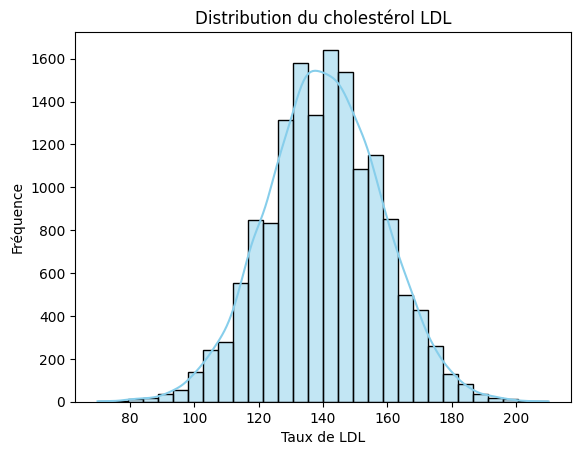

In [5]:
import seaborn as sns
sns.histplot(data['Cholesterol_LDL'], bins=30, kde=True, color='skyblue')
plt.title('Distribution du cholestérol LDL')
plt.xlabel('Taux de LDL')
plt.ylabel('Fréquence')
plt.show()

Graphe de corrélation entre les variables quantitatives du jeu de données

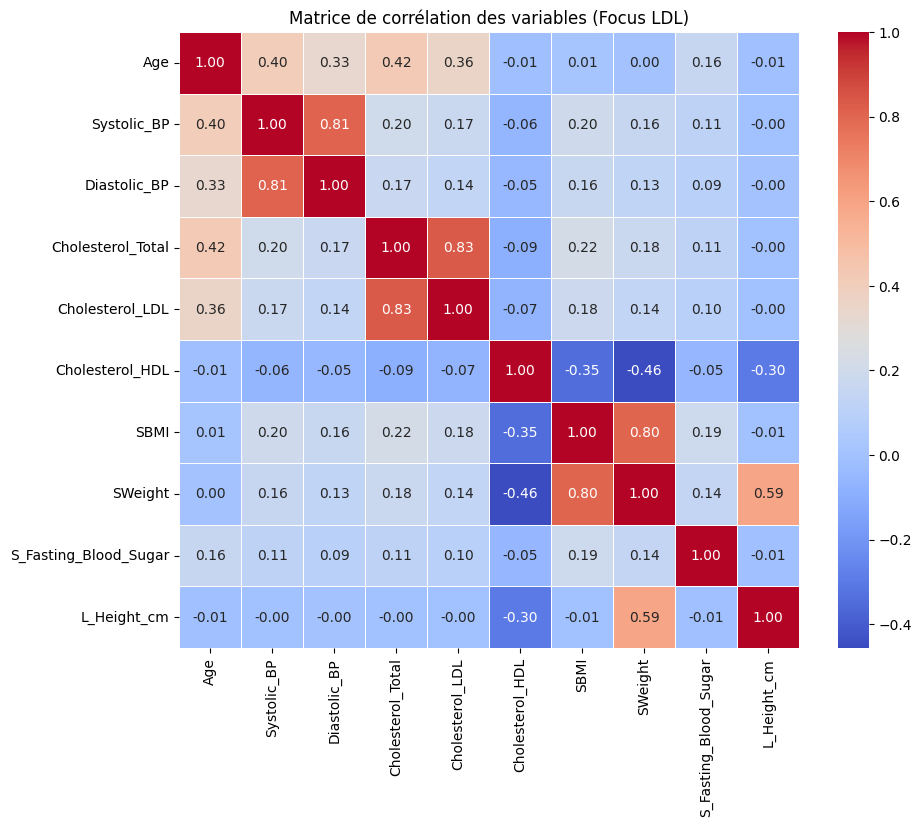

In [6]:
#on séléctionne uniquement les variables quantitatives
corr_matrix = data.select_dtypes(include=['number']).corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de corrélation des variables (Focus LDL)')
plt.show()

On remarque que la variable étudiée (Cholesterol_LDL) est fortement corrélé avec Cholesterol_HDL($0.83$) et légèrement avec l'age ($0.36$)

# Division du jeu de données 

In [7]:
from sklearn.model_selection import train_test_split 
Y=data["Cholesterol_LDL"]
X = data.drop(columns=['Cholesterol_LDL'])
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=11)


Standardisation des variables explicatives

In [8]:
from sklearn.preprocessing import StandardScaler  

scaler = StandardScaler()  
scaler.fit(X_train)  
X_train = scaler.transform(X_train)  
# Meme transformation sur le test
X_test = scaler.transform(X_test)

## Régression linéaire avec choix de modèle par régularisation avec un pénalisation Lasso

On va d'abord prendre le alpha par default soit $alpha=1$

In [9]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

regLasso = linear_model.Lasso()
regLasso.fit(X_train,Y_train)
prev=regLasso.predict(X_test)

print("MSE=",mean_squared_error(Y_test,prev))


MSE= 104.15974780370706


In [10]:
from sklearn.metrics import r2_score
print("R2=",r2_score(Y_test,prev))

R2= 0.6725005825786377


### Optimisation du paramètre de Lasso par validation croisée

In [11]:
from sklearn.model_selection import GridSearchCV
# grille de valeurs du paramètre alpha à optimiser
param=[{"alpha":[0.05,0.1,0.2,0.3,0.4,0.5,1]}]
regLasso = GridSearchCV(linear_model.Lasso(), param,cv=5,n_jobs=-1)

regLassOpt=regLasso.fit(X_train, Y_train)
best_predict=regLassOpt.predict(X_test)
# paramètre optimal
regLassOpt.best_params_["alpha"]
print("Meilleur R2 = %f, Meilleur paramètre = %s" % (regLassOpt.best_score_,regLassOpt.best_params_))
print("MSE=",mean_squared_error(best_predict,Y_test))

Meilleur R2 = 0.690835, Meilleur paramètre = {'alpha': 0.1}
MSE= 102.93954096874043


Le meilleur paramètre est alpha vaut 0.1 qui nous donne les coefficients suivants:

In [12]:
meilleur_modele = regLassOpt.best_estimator_

# Maintenant on peut voir les coefficients
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': meilleur_modele.coef_
})
print(coefficients.sort_values(by='Coefficient', ascending=False))

                   Variable  Coefficient
4         Cholesterol_Total    14.765059
0                       Age     0.088109
2               Systolic_BP     0.027934
1                    Gender    -0.000000
3              Diastolic_BP    -0.000000
5           Cholesterol_HDL     0.000000
6            Smoking_Status     0.000000
7       Alcohol_Consumption    -0.000000
8   Physical_Activity_Level    -0.000000
9            Family_History    -0.000000
10             Stress_Level     0.000000
11              Sleep_Hours    -0.000000
12                     SBMI    -0.000000
14    S_Fasting_Blood_Sugar    -0.000000
15              L_Height_cm    -0.000000
13                  SWeight    -0.013257


On peut voir que d'apres ce modèle lineaire avec pénalisation Lasso, c'est la quantité de cholestérol totale, l'age, la pression artérielle systolique et la variable lié au poids (Sweigth) qui influencent la prédiction de la quantité du mauvais cholestérol. En effet, la sélection de variables a annulé 12 des 16 variables initiales pour ne garder que celle précédemment citées. On note que le poids a une influence négative très légère, tandis que les autres variables citées agissent positivement sur le taux de LDL prédit. On va maintenant vérifier la qualité de nos prédictions.

## Graphique de comparaison entre la prédiction et des données réelles

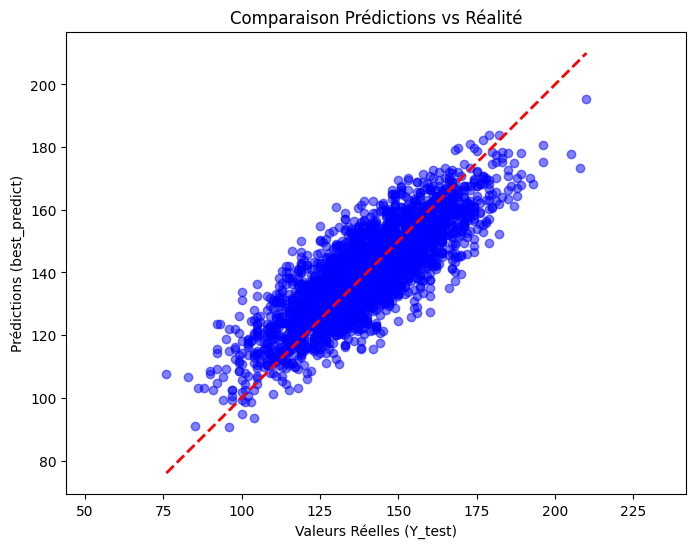

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test,best_predict, alpha=0.5, color='blue')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2) # La ligne de perfection
plt.xlabel('Valeurs Réelles (Y_test)')
plt.ylabel('Prédictions (best_predict)')
plt.title('Comparaison Prédictions vs Réalité')
plt.axis('equal')
plt.show()

 Le graphique montre une forte corrélation entre les valeurs réelles et les prédictions, le nuage de points suivant fidèlement la droite $y=x$, ce qui confirme la pertinence du modèle Lasso. On observe toutefois une légère tendance à la sous-estimation pour les valeurs de LDL les plus élevées (au-delà de 180), suggérant que le modèle est extrêmement fiable pour la majorité des patients mais perd un peu en précision sur les cas de cholestérol très sévère.

### Graphe des résidus

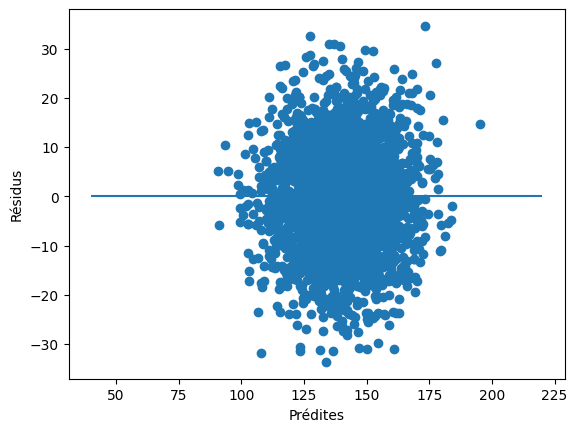

In [14]:
plt.plot(best_predict,Y_test-best_predict,"o")
plt.xlabel(u"Prédites")
plt.ylabel(u"Résidus")
plt.hlines(0,40,220)
plt.show()

L'analyse des résidus montre un nuage de points centré sur zéro et sans forme structurée (banane ou trompette). Cela valide l'hypothèse de l'homoscédasticité (variance constante des erreurs), ce qui est bon signe pour la fiabilité de notre modèle de régression Lasso. Cependant, on note la présence de quelques outliers avec des erreurs dépassant $\pm 30$, qui mériteraient une analyse approfondie. Pour cela on peut étudier la Mean Absolute Error (MAE) qui etudie l'écart moyen entre la donnée réelle et la donnée prédite

In [15]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Y_test, best_predict)
print(f"Erreur moyenne (MAE) : ",mae)

Erreur moyenne (MAE) :  8.048266201864996


Ici, la MAE est de $8.05$, ainsi cela signifie que les prédictions du taux de cholestérol LDL s'écartent en moyenne de plus ou moins $8.05$ unités des valeurs réelles observées sur le groupe de test.

## Autres méthodes d'optimisation des paramètres par validation croisée

*LassoCV* est optimisé spécifiquement pour l'utilisation de lasso. Il va tester une large gamme d'alphas tout seul et de manière beaucoup plus rapide grâce à l'algorithme de coordinate descent alors que précedemment j'avais fais une liste non exhaustivede alpha.
Cette fonction utilise l'algorithme de **coordinate descent** qui  contourne le problème de dérivabilité posé par la norme L1 du Lasso. En effet, pour optimiser le alpha, la valeur absolue de la pénalisation *L1* empêche l'utilisation de méthodes classique tel qu'un algorithme de descente.

In [16]:
from sklearn.linear_model import LassoCV, LassoLarsCV
model_cv = LassoCV(cv=5, random_state=11).fit(X_train, Y_train)
print(f"Meilleur alpha trouvé par LassoCV : {model_cv.alpha_}")

Meilleur alpha trouvé par LassoCV : 0.12964352215146593


On trouve avec cette méthode un alpha optimal envira égal à $0.13$ 

In [67]:
cv_model_predict=model_cv.predict(X_test)
print("MSE=",mean_squared_error(cv_model_predict,Y_test))
mae = mean_absolute_error(Y_test,cv_model_predict)
print(f"MAE=",mae)

MSE= 102.95051772339572
MAE= 8.04835882839635


L'utilisation de LassoCV a permis d'identifier un paramètre de régularisation optimal $\alpha \approx 0.13$. Bien que ce modèle présente un **MSE** légèrement supérieur sur le jeu de test par rapport à notre première approche par grille ($\alpha = 0.1$), il offre une meilleure garantie de généralisation. Quand au **MAE**, il est égal à celui trouvé avec alpha égale à $0.1$.

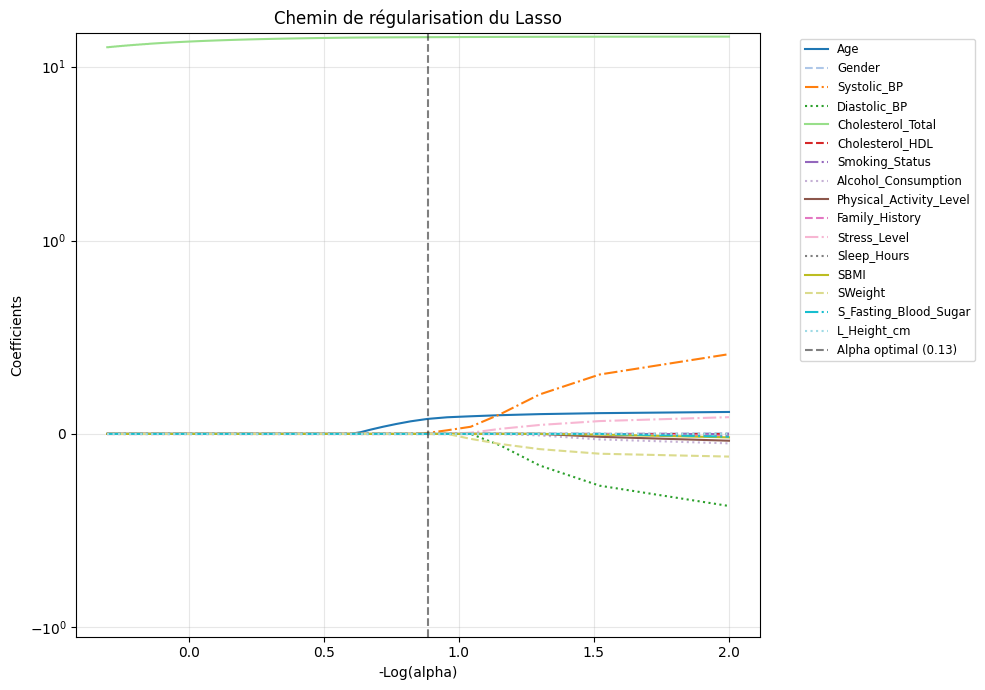

In [18]:
from itertools import cycle
from sklearn.linear_model import lasso_path

#echantillon d'alpha à tester
alphas_lasso, coefs_lasso, _ = lasso_path(X_train, Y_train, alphas=np.linspace(0.01, 2, 100))

plt.figure(figsize=(10, 7))
styles = cycle(['-', '--', '-.', ':'])
#couleur pour distinguer les variables
colors = plt.cm.tab20(np.linspace(0, 1, X_train.shape[1]))

neg_log_alphas_lasso = -np.log10(alphas_lasso)


for i in range(len(coefs_lasso)):
    plt.plot(neg_log_alphas_lasso, coefs_lasso[i], 
             label=X.columns[i], # On utilise les noms des colonnes
             linestyle=next(styles), 
             color=colors[i])

# 3. Ajout d'une ligne verticale pour ton alpha optimal (ex: 0.13)
alpha_opt = 0.13
plt.axvline(-np.log10(alpha_opt), linestyle='--', color='k', alpha=0.5, label=f'Alpha optimal ({alpha_opt})')
plt.yscale('symlog', linthresh=1)
plt.xlabel('-Log(alpha)')
plt.ylabel('Coefficients')
plt.title('Chemin de régularisation du Lasso')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small') # Légende à l'extérieur
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

On retrouve bien ce qu'on a vu précédemment le coefficients lié au cholesterol total est nettement plus grand que les autre qui sont proche de 0.

Pour conclure, avec la validation croisée on se rend compte que notre première estimation était très bonne mais que le alpha optima vaut $0.13$. et c'est coefficient sont les suivants.

In [19]:
coefficients.Coefficient=model_cv.coef_
print(coefficients.sort_values(by='Coefficient', ascending=False))

                   Variable  Coefficient
4         Cholesterol_Total    14.742471
0                       Age     0.076785
2               Systolic_BP     0.005465
1                    Gender    -0.000000
3              Diastolic_BP    -0.000000
5           Cholesterol_HDL     0.000000
6            Smoking_Status     0.000000
7       Alcohol_Consumption    -0.000000
8   Physical_Activity_Level    -0.000000
9            Family_History    -0.000000
10             Stress_Level     0.000000
11              Sleep_Hours    -0.000000
12                     SBMI    -0.000000
13                  SWeight    -0.000000
14    S_Fasting_Blood_Sugar    -0.000000
15              L_Height_cm    -0.000000


# Modèle linéaire sans sélection de Variables

# SVM/SVR

Nous allons réaliser une SVR car nous avons une variable qualitatives à expliquer.

on va d'abord réaliser une validation croisée pour optimiser nos paramètres pour La SVR. Pour commencer nous avons choisi un kernel linéaire ,pour pouvoir comparer les coefs avec ceux de la la regression avec Lasso.

In [45]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_svr_lin = [
    {
        'kernel': ['linear'], 
        'C': [0.1,0.2,0.3,0.4,0.5,0.7, 1,1.2,1.4,1.6,1.8,2],
        'epsilon': [0.01, 0.1, 0.5]
    }
]


grid_svr_lin = GridSearchCV(SVR(), param_svr_lin, cv=5, n_jobs=-1, scoring='r2')
grid_svr_lin.fit(X_train, Y_train)

print(f"Meilleur C : {grid_svr_lin.best_params_['C']}")
print(f"Meilleur R2 en validation croisée : {grid_svr_lin.best_score_:.4f}")

Meilleur C : 0.5
Meilleur R2 en validation croisée : 0.6900


On remarque que l'on a environ le même résultat( même score R2) que pour la regression Lasso

In [46]:
predict_SVR=grid_svr_lin.predict(X_test)
print("MSE=",mean_squared_error(predict_SVR,Y_test))

MSE= 103.29833787713329


On remarque même que l'erreur de prédiction est légérement plus élevé que Lasso avec les données tests. On peut regarder les coefficients de la regression pour savoir si ce sont les mêmes variables que pour lasso qui ont des gros coefs.

In [48]:
best_svr_lin = grid_svr_lin.best_estimator_

coef_svr = pd.DataFrame({
    'Variable': X.columns, 
    'Coefficient': best_svr_lin.coef_[0]  # [0] car coef_ est une matrice 2D ici
})

# 3. Tri pour voir les variables les plus influentes
print(coef_svr.sort_values(by='Coefficient', ascending=False))

                   Variable  Coefficient
4         Cholesterol_Total    14.805597
12                     SBMI     1.298905
15              L_Height_cm     0.881339
2               Systolic_BP     0.523199
11              Sleep_Hours     0.200572
1                    Gender     0.194951
5           Cholesterol_HDL     0.173927
10             Stress_Level     0.106756
9            Family_History     0.054482
6            Smoking_Status     0.051509
0                       Age     0.046245
14    S_Fasting_Blood_Sugar     0.034111
8   Physical_Activity_Level     0.024908
7       Alcohol_Consumption    -0.150301
3              Diastolic_BP    -0.440867
13                  SWeight    -1.599434


On remarque que le cholesterol total a toujours une importance significative avec ici la variable du poids et la variable de l'IMC ainsi que la taille.

On va passer maintenant a des kernels différents pour vois si on a des meilleurs résultats.

# Autres Kernels

In [51]:
param_grid_SVR = [
    {
        # On garde le RBF car c'est le standard, 
        # mais on reste sur des valeurs de C raisonnables
        'kernel': ['rbf'], 
        'C': [0.5, 1, 5, 10], 
        'gamma': ['scale'], # 'scale' est souvent le meilleur choix statistique
        'epsilon': [0.1, 0.05] # On affine la précision du tube
    },
    {
        # Pour le Poly, on reste sur du degré 2 (courbe simple)
        # car ton arbre montre qu'il n'y a pas de complexité fractale
        'kernel': ['poly'], 
        'degree': [2], 
        'C': [1, 5],
        'epsilon': [0.1]
    }
]
grid_svr_nonlin = GridSearchCV(SVR(), param_grid_SVR, cv=5, scoring='r2', n_jobs=-1)
grid_svr_nonlin.fit(X_train, Y_train)

print(f"Meilleur Kernel : {grid_svr_nonlin.best_params_['kernel']}")
print(f"Nouveau meilleur R2 : {grid_svr_nonlin.best_score_:.4f}")

Meilleur Kernel : rbf
Nouveau meilleur R2 : 0.6634


In [66]:
predict_SVR_rbf=grid_svr_nonlin.predict(X_test)
print("MSE=",mean_squared_error(predict_SVR_rbf,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_SVR_rbf))

MSE= 112.04788126813392
MAE= 8.419425047459526


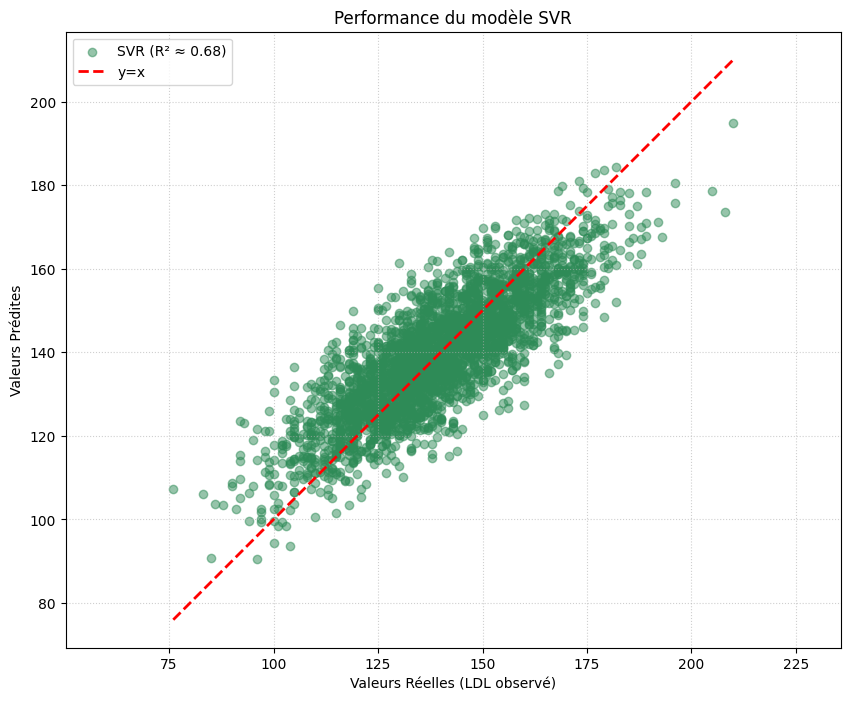

In [75]:
from sklearn.metrics import r2_score

r2_svr = r2_score(Y_test, predict_SVR)

# 2. Création du graphique
plt.figure(figsize=(10, 8))

# Affichage des points du SVR
plt.scatter(Y_test, predict_SVR, alpha=0.5, color='seagreen', marker='o', label=f'SVR (R² ≈ {r2_svr:.2f})')

# 3. Ligne de perfection (y = x) pour bien voir l'alignement
lims = [min(Y_test.min(), predict_SVR.min()), max(Y_test.max(), predict_SVR.max())]
plt.plot(lims, lims, 'r--', lw=2, label='y=x')

# 4. Habillage
plt.xlabel('Valeurs Réelles (LDL observé)')
plt.ylabel('Valeurs Prédites')
plt.title('Performance du modèle SVR')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')

plt.show()

Ainsi, on avait un meilleur résultat avec le kernel linéaire par rapport aux kernels rbf polynomial.
Par conséquent jusqu'à présent, nous avons environ les mêmes résultats pour toute les méthodes testées mais puique la méthode de régression linéaire avec pénalisation Lasso est plus facile à implémenter, nous allons garder celle là.

# Arbre binaire

## Random Forest

In [61]:
import math

from sklearn.ensemble import RandomForestRegressor 
p= X_train.shape[1] 

# On calcule les valeurs proches de p/3
p_tiers = math.floor(p/3) 
p_tiers_sup = math.ceil(p/3)

# On injecte ces valeurs dans la grille du RandomForestRegressor
param_grid_rf = {
    'max_features': [p_tiers, p_tiers_sup, 'sqrt'], # On teste p/3 vs les classiques
    'max_depth': [None,2,3,4,5,6,7,8,9, 10]
}
rf= GridSearchCV(RandomForestRegressor(n_estimators=100),
        param_grid_rf,cv=5,n_jobs=-1)
rfOpt=rf.fit(X_train, Y_train)


print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - rfOpt.best_score_,rfOpt.best_params_))

Meilleur score = 0.319324, Meilleur paramètre = {'max_depth': 10, 'max_features': 6}


In [64]:
predict_RF=rfOpt.predict(X_test)
print("MSE=",mean_squared_error(predict_RF,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_RF))

MSE= 106.54638723617171
MAE= 8.182751999842992


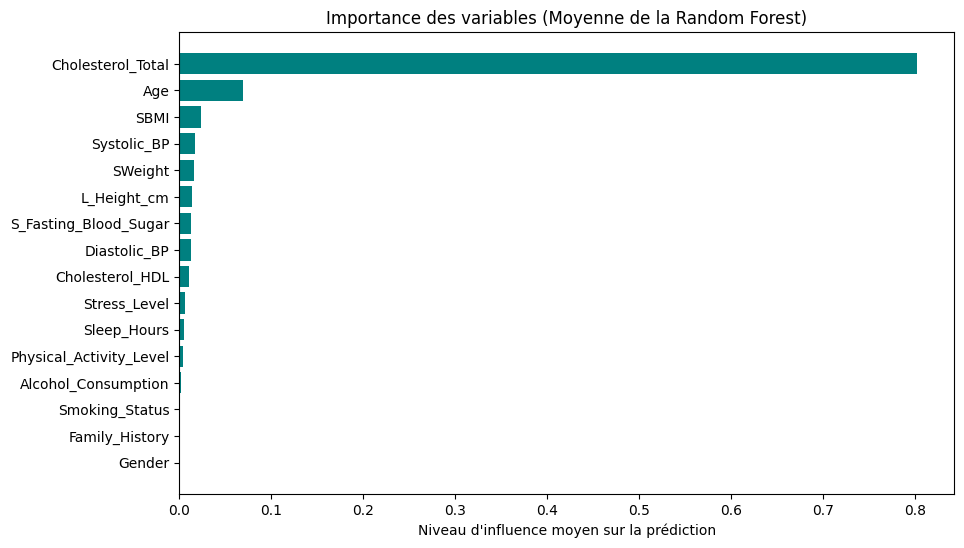

In [71]:
importances = rfOpt.best_estimator_.feature_importances_
labels = X.columns

df_importance = pd.DataFrame({'Variable': labels, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_importance['Variable'], df_importance['Importance'], color='teal')
plt.xlabel("Niveau d'influence moyen sur la prédiction")
plt.title("Importance des variables (Moyenne de la Random Forest)")
plt.show()

même conclusion que les méthodes précédentes

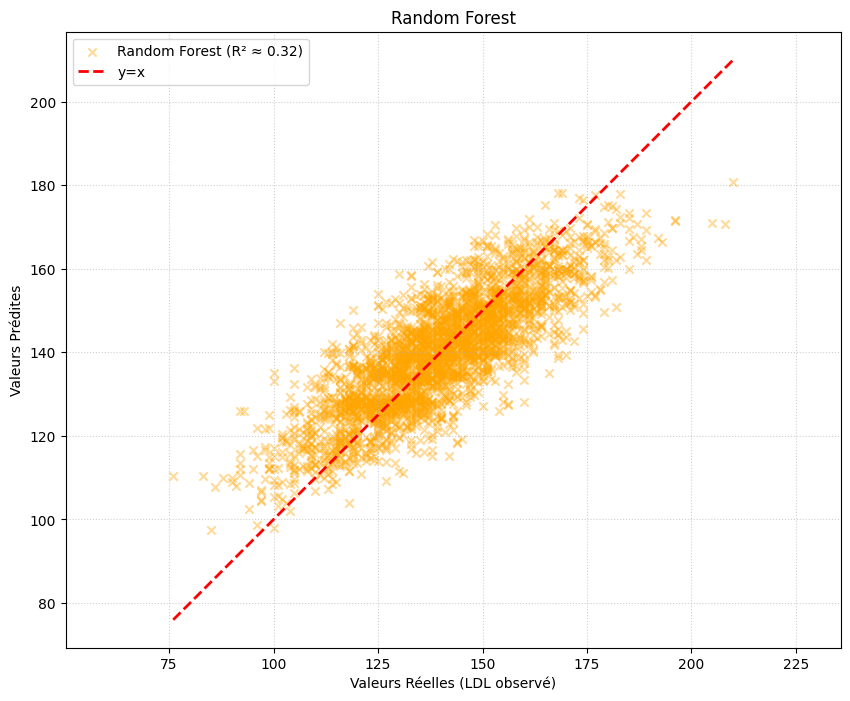

In [77]:
plt.figure(figsize=(10, 8))
plt.scatter(Y_test,predict_RF, alpha=0.4, color='orange', marker='x', label=f'Random Forest (R² ≈ 0.32)')

lims = [min(Y_test.min(), predict_RF.min()), max(Y_test.max(), predict_RF.max())]
plt.plot(lims, lims, 'r--', lw=2, label='y=x')

plt.xlabel('Valeurs Réelles (LDL observé)')
plt.ylabel('Valeurs Prédites')
plt.title('Random Forest')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')

plt.show()

## CART

In [81]:
from sklearn.tree import DecisionTreeRegressor

param_cart = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [2,3,4,5,6,7,8,9, 10],
    'criterion': ['squared_error', 'friedman_mse']
}


grid_cart = GridSearchCV(DecisionTreeRegressor(random_state=11), 
                         param_cart, cv=5, scoring='r2', n_jobs=-1)
cart_opt = grid_cart.fit(X_train, Y_train)

# 3. Prédictions et Scores
predict_cart = cart_opt.predict(X_test)

print(f"Meilleurs paramètres CART : {cart_opt.best_params_}")
print(f"R² CART : {r2_score(Y_test, predict_cart):.4f}")

Meilleurs paramètres CART : {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 9}
R² CART : 0.6701


In [83]:

print("MSE=",mean_squared_error(predict_cart,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_cart))

MSE= 104.91868857071766
MAE= 8.116990874278239


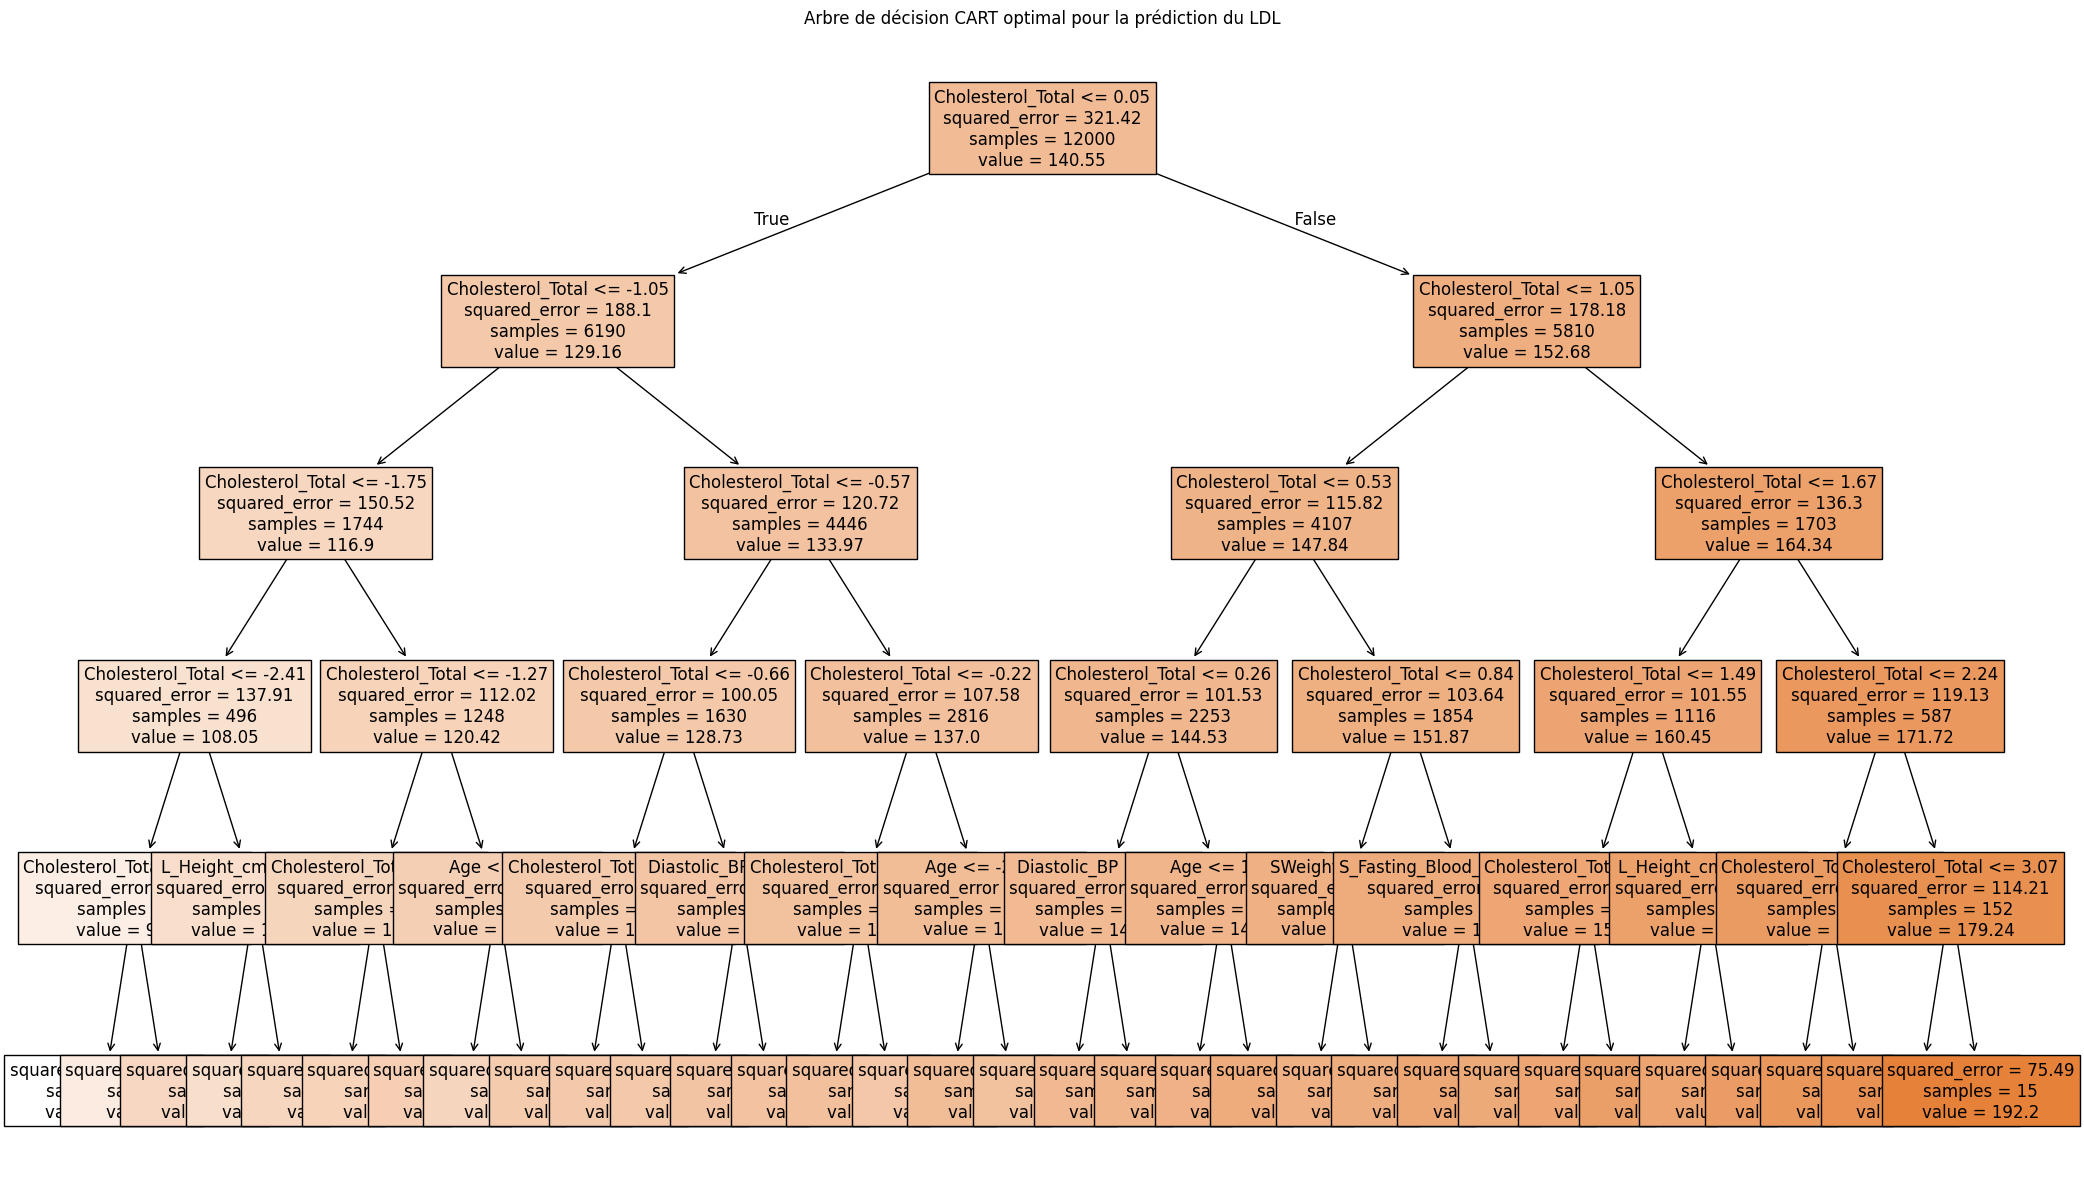

In [82]:
from sklearn import tree

plt.figure(figsize=(25, 15))
tree.plot_tree(cart_opt.best_estimator_, 
               feature_names=X.columns, 
               filled=True, 
               fontsize=12,
               precision=2)
plt.title("Arbre de décision CART optimal pour la prédiction du LDL")
plt.show()

# Boosting

# Réseaux de neurones